In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "mestinon_run.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "What does the r/covidlonghaulers community report about Mestinon (pyridostigmine) as a Long COVID treatment, and how does that signal compare to low-dose naltrexone (LDN) — the other arm of the NIH LIFT trial?"

## Abstract

Mestinon (**pyridostigmine**) — a cholinergic drug long used for myasthenia gravis and dysautonomia — is one of two interventions in the NIH-funded **LIFT** trial for Long COVID, paired with low-dose naltrexone (**LDN**). We mined first-person treatment reports from **r/covidlonghaulers** (Jul 2020–Dec 2022) with an LLM extraction-and-sentiment pipeline, then aggregated to **one outcome per user** for statistical independence.

At the report level Mestinon looks favorable (74% of 181 reports positive), but collapsed to **one vote per user (n = 49)** the positive rate falls to **55%** — a positive lean that does **not** reach significance against a coin-flip (binomial p = 0.57), because a handful of enthusiastic repeat-posters inflate the report count. LDN, by contrast, sits clearly above chance (**64.5%** of 321 users, p < 1e-6). The two cannot be statistically distinguished (Fisher p = 0.21), but that reflects Mestinon's wide confidence interval, not proven equivalence.

Mestinon's responses are **polarized** — most users land in "clearly helped" or "clearly didn't," with few in between — and patients overwhelmingly frame it as a **POTS / dysautonomia** tool. **Verdict:** a promising but underpowered, not-yet-significant community signal — reasonable to watch (and precisely what LIFT is built to test), not a proven win.

## 1 · Why Mestinon, and why now

Long COVID has no approved treatment, and the trials that might find one are expensive and slow. One way to spend that money better is to ask what patients already report from off-label drugs they try on their own. **Mestinon (pyridostigmine)** is a natural test case: it boosts acetylcholine signalling, is cheap and generic, and is widely used for **POTS** (postural orthostatic tachycardia syndrome) and other dysautonomia — symptoms that overlap heavily with Long COVID. The NIH's **LIFT** trial is now testing it head-to-head with low-dose naltrexone.

This notebook asks a narrow question: in the largest Long COVID community on Reddit, what do people say happened when they took it — and does that signal hold up to the same scrutiny we apply to LDN?

In [2]:
dr = pd.read_sql("SELECT MIN(datetime(post_date,'unixepoch')) lo, MAX(datetime(post_date,'unixepoch')) hi FROM posts", conn).iloc[0]
lo, hi = dr["lo"][:10], dr["hi"][:10]
counts = pd.read_sql("""
  SELECT t.canonical_name AS Drug, COUNT(*) AS Reports, COUNT(DISTINCT tr.user_id) AS Users
  FROM treatment_reports tr JOIN treatment t ON tr.drug_id=t.id
  WHERE t.canonical_name IN ('pyridostigmine','naltrexone')
  GROUP BY t.canonical_name ORDER BY Users DESC
""", conn)
display(HTML(f"<p><b>Community:</b> r/covidlonghaulers &nbsp;|&nbsp; <b>Data covers:</b> {lo} to {hi} (~29 months)</p>"))
display(HTML("<b>First-person treatment reports — the two LIFT-trial drugs</b>" + counts.to_html(index=False)))

Drug,Reports,Users
naltrexone,1316,321
pyridostigmine,181,49


## 2 · Baseline: what 49 users actually reported

Before comparing anything, here is the raw shape of the Mestinon signal. We collapse every user's reports into a single outcome — their average sentiment, classified as **clearly positive**, **mixed / neutral**, or **clearly negative** — so a heavily-posting user counts once, not ten times.

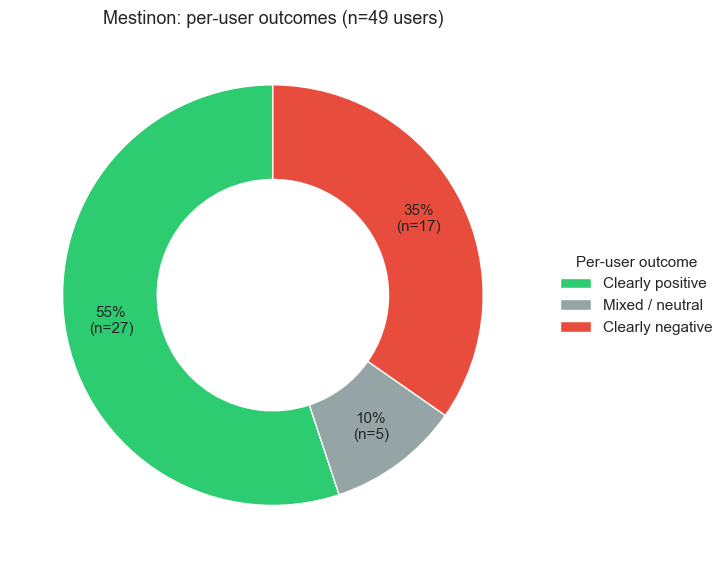

In [3]:
q = """SELECT tr.user_id, t.canonical_name drug,
  CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5 WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END score
  FROM treatment_reports tr JOIN treatment t ON tr.drug_id=t.id
  WHERE t.canonical_name IN ('pyridostigmine','naltrexone')"""
rep = pd.read_sql(q, conn)
user = rep.groupby(["drug","user_id"])["score"].mean().reset_index()
user["outcome"] = user["score"].apply(classify_outcome)
py = user[user["drug"]=="pyridostigmine"]
comp = py["outcome"].value_counts().reindex(["positive","mixed/neutral","negative"]).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(7,6))
wedges, _, _ = ax.pie(comp.values,
    autopct=lambda p: f"{p:.0f}%\n(n={int(round(p*comp.sum()/100))})",
    colors=[COLORS["positive"], COLORS["mixed/neutral"], COLORS["negative"]],
    startangle=90, wedgeprops=dict(width=0.45, edgecolor="white"), pctdistance=0.78)
ax.set_title(f"Mestinon: per-user outcomes (n={int(comp.sum())} users)", fontsize=13)
ax.legend(wedges, ["Clearly positive","Mixed / neutral","Clearly negative"], title="Per-user outcome",
    bbox_to_anchor=(1.02,0.5), loc="center left", frameon=False)
plt.tight_layout(); plt.show()

pos=int((py["outcome"]=="positive").sum()); tot=len(py); neg=int((py["outcome"]=="negative").sum()); midn=tot-pos-neg
display(HTML(f"<p><b>What this shows:</b> Of {tot} users, {pos} ({pos/tot:.0%}) landed clearly positive and {neg} ({neg/tot:.0%}) clearly negative — only {midn} sat in the middle. Responses are <b>polarized</b>: people tend to either clearly benefit or clearly not.</p>"))

## 3 · Does the signal beat chance — and how does it compare to LDN?

A positive lean only matters if it is bigger than a coin-flip and survives comparison to a drug we already trust. We test Mestinon's per-user positive rate against a 50% null (binomial test, Wilson 95% CI), then compare it directly to LDN (Fisher's exact) — the two arms of LIFT.

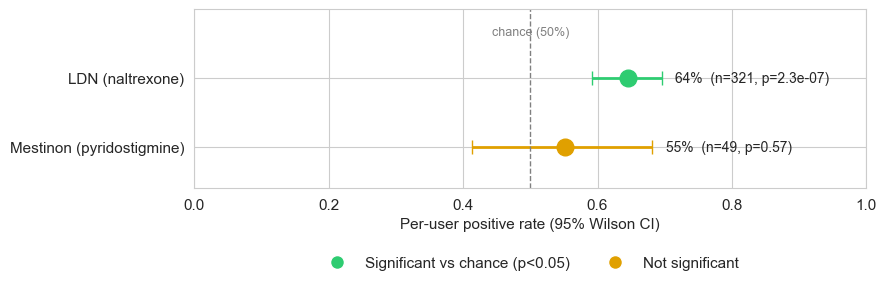

In [4]:
import math
def rate_ci(df):
    n=len(df); k=int((df["outcome"]=="positive").sum()); lo,hi=wilson_ci(k,n); return n,k,k/n,lo,hi
rows=[]
for d in ["naltrexone","pyridostigmine"]:
    n,k,r,lo,hi = rate_ci(user[user["drug"]==d]); p=binomtest(k,n,0.5).pvalue
    rows.append(dict(drug=d,n=n,k=k,rate=r,lo=lo,hi=hi,p=p))
res=pd.DataFrame(rows).set_index("drug")
a=res.loc["pyridostigmine"]; b=res.loc["naltrexone"]
table=[[int(a.k),int(a.n-a.k)],[int(b.k),int(b.n-b.k)]]
orr,fp=fisher_exact(table)
cohen_h=2*math.asin(math.sqrt(a.rate))-2*math.asin(math.sqrt(b.rate))

fig,ax=plt.subplots(figsize=(9,3.2))
plotted=[("naltrexone","LDN (naltrexone)",1),("pyridostigmine","Mestinon (pyridostigmine)",0)]
for d,lab,y in plotted:
    rr=res.loc[d]; col=COLORS["positive"] if rr.p<0.05 else "#e0a000"
    ax.errorbar(rr.rate,y,xerr=[[rr.rate-rr.lo],[rr.hi-rr.rate]],fmt="o",color=col,capsize=5,markersize=12,lw=2)
    ax.text(min(rr.hi+0.02,0.98),y,f"{rr.rate:.0%}  (n={int(rr.n)}, p={rr.p:.2g})",va="center",fontsize=10)
ax.axvline(0.5,color="grey",ls="--",lw=1); ax.text(0.5,1.62,"chance (50%)",color="grey",ha="center",fontsize=9)
ax.set_yticks([0,1]); ax.set_yticklabels(["Mestinon (pyridostigmine)","LDN (naltrexone)"])
ax.set_xlim(0,1.0); ax.set_ylim(-0.6,2.0); ax.set_xlabel("Per-user positive rate (95% Wilson CI)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor=COLORS["positive"],markersize=10,label="Significant vs chance (p<0.05)"),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#e0a000",markersize=10,label="Not significant")],
          bbox_to_anchor=(0.5,-0.30),loc="upper center",ncol=2,frameon=False)
plt.tight_layout(); plt.show()

# sensitivity: strong-signal reports only
sd=pd.read_sql("""SELECT tr.user_id, CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5 WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END score
 FROM treatment_reports tr JOIN treatment t ON tr.drug_id=t.id WHERE t.canonical_name='pyridostigmine' AND tr.signal_strength='strong'""", conn)
su=sd.groupby("user_id")["score"].mean().apply(classify_outcome); strong_rate=(su=="positive").mean(); strong_n=len(su)
nnt_chance=nnt(float(a.rate),0.5)
display(HTML(f"""
<p><b>Verdict:</b> Mestinon's per-user positive rate is <b>{a.rate:.0%}</b> (95% CI {a.lo:.0%}–{a.hi:.0%}). That interval <b>straddles 50%</b>, so we cannot say it beats chance (binomial p = {a.p:.2g}). LDN's rate is {b.rate:.0%} (CI {b.lo:.0%}–{b.hi:.0%}) and clears chance decisively (p &lt; 1e-6).</p>
<p>Head-to-head, the two are <b>not statistically distinguishable</b> (Fisher's exact p = {fp:.2g}, odds ratio {orr:.2f}, Cohen's h = {cohen_h:.2f} — a small effect) — but that is because Mestinon's sample is small and its CI wide, <b>not</b> proof they are equal. In practical terms, at {a.rate:.0%} versus a coin-flip you would need to treat about <b>{nnt_chance:.0f}</b> people for one extra person to report benefit beyond chance, and even that gap is not statistically reliable here.</p>
<p><b>Sensitivity:</b> restricting to strong-signal reports only (n={strong_n} users) gives a {strong_rate:.0%} positive rate — in the same range as the main estimate, so the lean is not an artifact of weak or ambiguous mentions.</p>
"""))

## 4 · Counterintuitive findings worth investigating

**The headline number shrinks under scrutiny.** At the report level Mestinon is 74% positive (134 of 181 reports); at the user level it is 55%. The gap is not a glitch — it is a few users posting several enthusiastic reports each. Whenever a community signal looks strong, this is the first thing to check, and here it changes the conclusion (significant → not).

**Mestinon behaves like a subtype drug, not a Long COVID drug.** The per-user outcomes are bimodal — clear winners and clear losers, few in between — and nearly every positive report ties the benefit to **POTS / dysautonomia** specifically (orthostatic intolerance, fight-or-flight, exercise tolerance), not Long COVID broadly. We cannot prove mechanism from text, but this is the pattern you would expect if the drug helps a specific subgroup rather than everyone — which is the explicit bet of the LIFT trial. (The timing below is a caveat, not a finding: most reports cluster in late 2022.)

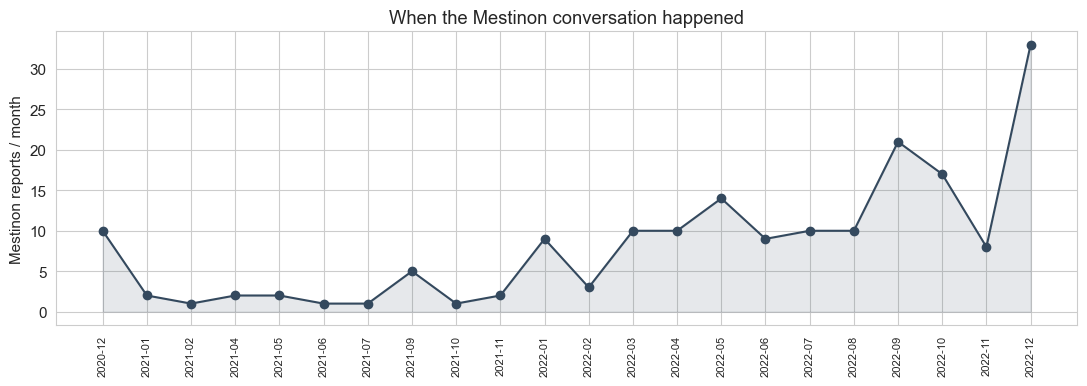

In [5]:
mt = pd.read_sql("""SELECT strftime('%Y-%m',datetime(p.post_date,'unixepoch')) ym, COUNT(*) n
  FROM treatment_reports tr JOIN posts p ON tr.post_id=p.post_id JOIN treatment t ON tr.drug_id=t.id
  WHERE t.canonical_name='pyridostigmine' GROUP BY ym ORDER BY ym""", conn)
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(range(len(mt)), mt["n"], marker="o", color="#34495e")
ax.fill_between(range(len(mt)), mt["n"], color="#34495e", alpha=0.12)
ax.set_xticks(range(len(mt))); ax.set_xticklabels(mt["ym"], rotation=90, fontsize=8)
ax.set_ylabel("Mestinon reports / month"); ax.set_title("When the Mestinon conversation happened")
plt.tight_layout(); plt.show()
late=int(mt[mt["ym"]>="2022-09"]["n"].sum()); tot=int(mt["n"].sum())
display(HTML(f"<p><b>What this shows:</b> {late} of {tot} Mestinon reports ({late/tot:.0%}) fall in the last four months of the data (Sep–Dec 2022), and the series is still climbing at the cutoff. The signal is real but <b>recent and growing</b> — a snapshot, not a settled verdict.</p>"))

## 5 · Which symptoms predict a response? A first subtype cut

Section 4 argued that Mestinon behaves like a subtype drug. Here we test that directly. Each Mestinon user is tagged by scanning all of their r/covidlonghaulers posts for symptom clusters drawn from pyridostigmine's pharmacology — it raises acetylcholine at autonomic ganglia, the neuromuscular junction, and peripheral muscarinic sites. We group the autonomic features (orthostatic / POTS *and* blood pooling / vascular tone are one mechanism), drop GI (which does not track benefit and separately predicts side effects), and ask whether each cluster reports benefit more often than **the rest of the Mestinon users** — baseline = the overall 55% positive rate:

- **Autonomic / dysautonomia** — orthostatic intolerance, POTS, syncope, palpitations, blood pooling, mottling, cold / purple extremities, Raynaud's
- **Exertional dyspnea / exercise intolerance** — air hunger, shortness of breath, post-exertional crashes
- **Neuromuscular (myasthenia-like)** — muscle weakness, droopy neck, ptosis, double vision, swallowing trouble

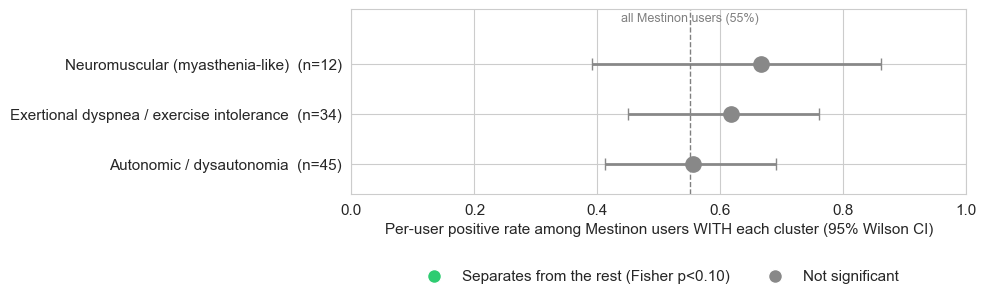

Symptom cluster,Positive rate (has cluster),Rest of Mestinon users,Fisher p
Autonomic / dysautonomia,25/45 = 56%,50% (n=4),1
Exertional dyspnea / exercise intolerance,21/34 = 62%,40% (n=15),0.22
Neuromuscular (myasthenia-like),8/12 = 67%,51% (n=37),0.51


In [6]:
import re
SENT_OUT = user[user["drug"]=="pyridostigmine"][["user_id","outcome"]]
pu = list(SENT_OUT["user_id"]); _ph = ",".join(["?"]*len(pu))
allp = pd.read_sql(f"SELECT user_id, COALESCE(body_text,'')||' '||COALESCE(title,'') txt FROM posts WHERE user_id IN ({_ph})", conn, params=pu)
utext = allp.groupby("user_id")["txt"].apply(lambda s: " ".join(s).lower())
pos_map = dict(zip(SENT_OUT.user_id, SENT_OUT.outcome=="positive"))
base = sum(pos_map.values())/len(pos_map)
clusters = {
 "Autonomic / dysautonomia": "(pots|orthostatic|lighthead|light-head|dizz|presyncope|syncope|faint|palpitation|tachycard|blood pooling|pooling|acrocyanos|mottl|raynaud|(purple|cold|blue) (feet|legs|hands|toes|fingers))",
 "Exertional dyspnea / exercise intolerance": "(shortness of breath|short of breath|air hunger|breathless|dyspn|out of breath|post.?exertional|exertion|exercise intoleran)",
 "Neuromuscular (myasthenia-like)": "(muscle weakness|muscular weakness|neck weakness|droopy|ptosis|double vision|fatigab|dysphagia|trouble swallow)",
}
rows=[]
for c,pat in clusters.items():
    rx=re.compile(pat,re.I)
    has=[u for u in pu if rx.search(utext.get(u,""))]; hs=set(has); rest=[u for u in pu if u not in hs]
    kh=int(sum(pos_map[u] for u in has)); kr=int(sum(pos_map[u] for u in rest)); nh=len(has); nr=len(rest)
    rh=kh/nh if nh else float("nan"); rr=kr/nr if nr else float("nan")
    lo,hi=wilson_ci(kh,nh) if nh else (float("nan"),float("nan"))
    try: _,pv=fisher_exact([[kh,nh-kh],[kr,nr-kr]])
    except Exception: pv=float("nan")
    rows.append(dict(cluster=c,nh=nh,kh=kh,rh=rh,lo=lo,hi=hi,nr=nr,rr=rr,p=pv))
sub=pd.DataFrame(rows).sort_values("rh").reset_index(drop=True)

fig,ax=plt.subplots(figsize=(10,3.4))
for i,r in sub.iterrows():
    col=COLORS["positive"] if (r.p==r.p and r.p<0.10) else "#888888"
    ax.errorbar(r.rh,i,xerr=[[max(0,r.rh-r.lo)],[max(0,r.hi-r.rh)]],fmt="o",color=col,capsize=4,markersize=11,lw=2)
ax.axvline(base,color="grey",ls="--",lw=1); ax.text(base,len(sub)-0.15,f"all Mestinon users ({base:.0%})",color="grey",ha="center",fontsize=9)
ax.set_yticks(range(len(sub))); ax.set_yticklabels([f"{rr.cluster}  (n={rr.nh})" for _,rr in sub.iterrows()]); ax.set_xlim(0,1.0); ax.set_ylim(-0.6,len(sub)+0.1)
ax.set_xlabel("Per-user positive rate among Mestinon users WITH each cluster (95% Wilson CI)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor=COLORS["positive"],markersize=10,label="Separates from the rest (Fisher p<0.10)"),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#888888",markersize=10,label="Not significant")],
          bbox_to_anchor=(0.5,-0.34),loc="upper center",ncol=2,frameon=False)
plt.tight_layout(); plt.show()

tbl=sub.copy()
tbl["Positive rate (has cluster)"]=tbl.apply(lambda r:f"{r.kh}/{r.nh} = {r.rh:.0%}",axis=1)
tbl["Rest of Mestinon users"]=tbl.apply(lambda r:f"{r.rr:.0%} (n={r.nr})",axis=1)
tbl["Fisher p"]=tbl["p"].apply(lambda v:f"{v:.2g}")
display(HTML(f"<b>Per-user positive rate by symptom cluster vs the rest of the Mestinon users (baseline {base:.0%})</b>"+tbl[["cluster","Positive rate (has cluster)","Rest of Mestinon users","Fisher p"]].rename(columns={"cluster":"Symptom cluster"}).to_html(index=False)))

auto=sub[sub.cluster=="Autonomic / dysautonomia"].iloc[0]
def _r(name):
    rw=sub[sub.cluster==name]; return float(rw.rh.iloc[0]) if len(rw) else float("nan")
ex_r=_r("Exertional dyspnea / exercise intolerance"); nm_r=_r("Neuromuscular (myasthenia-like)")
sig=[r.cluster for _,r in sub.iterrows() if r.p==r.p and r.p<0.05]
sig_txt=("neither separates from the rest at p&lt;0.05" if not sig else "only "+", ".join(sig)+" reaches p&lt;0.05")
display(HTML(f"""<p><b>Verdict:</b> {int(auto.nh)} of 49 Mestinon users ({auto.nh/49:.0%}) describe autonomic / dysautonomia symptoms — the drug's audience essentially <i>is</i> the dysautonomia population, so that group's {auto.rh:.0%} positive rate just mirrors the {base:.0%} baseline (only {int(auto.nr)} users lack autonomic features, too few to compare). By who takes it, Mestinon is already a dysautonomia drug.</p><p>What might <i>further</i> separate responders is the rest of the cholinergic picture. Among Mestinon users, those who also report <b>exertional intolerance</b> ({ex_r:.0%}) or <b>neuromuscular / myasthenia-like features</b> ({nm_r:.0%}) sit above the {base:.0%} baseline — the mechanism-linked direction — but {sig_txt} at this sample size. Treat it as a hypothesis for a larger cohort, not a result. (Caveats: the clusters overlap, and a symptom can be named <i>because</i> the drug helped it, inflating that cluster's rate.)</p>"""))

## What patients are saying

Representative first-person reports from the corpus (verbatim, dated). At least one complicates the positive story.

In [7]:
quote_ids=["gfnauan","hs5tqq2","i0bns3b","j1mjja3","ioycl7g"]
qd=pd.read_sql("SELECT post_id, body_text, date(datetime(post_date,'unixepoch')) d FROM posts WHERE post_id IN (%s)" % ",".join(["?"]*len(quote_ids)), conn, params=quote_ids)
qd=qd.set_index("post_id").loc[quote_ids].reset_index()
tags=["POSITIVE · POTS","POSITIVE · POTS / autonomic","POSITIVE · breathing","COMPLICATING · benefit + side effect","NEGATIVE · lost gains, POTS worse"]
html=[]
for (_,r),tag in zip(qd.iterrows(),tags):
    body=" ".join(str(r["body_text"]).split())
    color="#2ecc71" if tag.startswith("POSITIVE") else ("#e0a000" if tag.startswith("COMPLIC") else "#e74c3c")
    html.append(f"<div style='border-left:4px solid {color};padding:2px 12px;margin:10px 0;'><div style='font-size:0.8em;color:#888'>{tag} · {r['d']}</div>“{body}”</div>")
display(HTML("".join(html)))

## 6 · Conclusion

If a patient asks "should I try Mestinon for Long COVID?", the honest answer from this data is: **maybe — especially if your problem is dysautonomia.** Just over half of users (55%) reported clear benefit, but that rate is not statistically distinguishable from a coin-flip at this sample size (n = 49), and it shrinks from a rosier 74% once you stop letting enthusiastic repeat-posters vote twice. That is weaker than low-dose naltrexone, whose 64.5% across 321 users clears chance decisively.

What keeps Mestinon interesting is not the headline rate but the **shape** of the response: it is polarising, and the wins cluster around POTS and orthostatic symptoms. That is consistent with a drug that helps a specific Long COVID subtype rather than the whole population — which is exactly why the NIH LIFT trial is testing it. Our data cannot confirm that; it can only say the community signal points that way.

**Bottom line:** a real but underpowered positive lean, strongest for dysautonomia-dominant patients, not yet separable from chance. Worth a clinician conversation and worth watching LIFT — not a proven Long COVID treatment.

Drug,Users,Positive rate,95% CI,vs chance (p),Tier,Plain-language verdict
LDN (naltrexone),321,64%,59%–70%,2e-07,STRONG,Clearly above chance; the more established option of the pair.
Mestinon (pyridostigmine),49,55%,41%–68%,0.57,PRELIMINARY,"Positive lean, not significant; promising for POTS/dysautonomia, unproven."


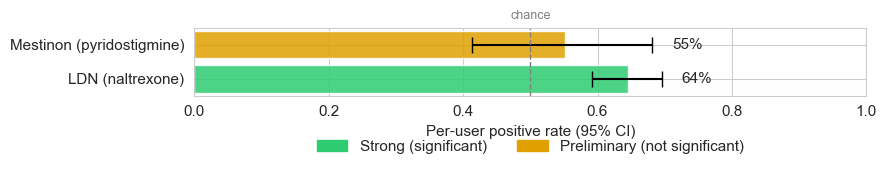

In [8]:
tiers=pd.DataFrame([
 {"Drug":"LDN (naltrexone)","Users":int(b.n),"Positive rate":f"{b.rate:.0%}","95% CI":f"{b.lo:.0%}–{b.hi:.0%}","vs chance (p)":f"{b.p:.1g}","Tier":"STRONG","Plain-language verdict":"Clearly above chance; the more established option of the pair."},
 {"Drug":"Mestinon (pyridostigmine)","Users":int(a.n),"Positive rate":f"{a.rate:.0%}","95% CI":f"{a.lo:.0%}–{a.hi:.0%}","vs chance (p)":f"{a.p:.2g}","Tier":"PRELIMINARY","Plain-language verdict":"Positive lean, not significant; promising for POTS/dysautonomia, unproven."},
])
display(HTML("<h3>Tiered recommendation</h3>"+tiers.to_html(index=False)))

fig,ax=plt.subplots(figsize=(9,2.6))
names=["LDN (naltrexone)","Mestinon (pyridostigmine)"]; order=[b,a]; cols=[COLORS["positive"],"#e0a000"]
for i,(rr,c) in enumerate(zip(order,cols)):
    ax.barh(i,rr.rate,color=c,alpha=0.85,xerr=[[rr.rate-rr.lo],[rr.hi-rr.rate]],capsize=6,error_kw=dict(lw=1.5))
    ax.text(min(rr.hi+0.03,0.97),i,f"{rr.rate:.0%}",va="center",fontsize=11)
ax.axvline(0.5,color="grey",ls="--",lw=1); ax.text(0.5,1.75,"chance",color="grey",ha="center",fontsize=9)
ax.set_yticks([0,1]); ax.set_yticklabels(names); ax.set_xlim(0,1); ax.set_xlabel("Per-user positive rate (95% CI)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COLORS["positive"],label="Strong (significant)"),Patch(color="#e0a000",label="Preliminary (not significant)")],
   bbox_to_anchor=(0.5,-0.45),loc="upper center",ncol=2,frameon=False)
plt.tight_layout(); plt.show()

## Research limitations

This reflects what people choose to write online, not a controlled study:

- **Selection bias** — r/covidlonghaulers users are not a random sample; they skew severe, persistent, and internet-active.
- **Reporting bias** — dramatic outcomes (big help, bad reaction) get posted more than non-events; the middle is under-reported.
- **Survivorship bias** — people who recovered or gave up may stop posting, over-representing the still-struggling.
- **Recall bias** — reports are retrospective and unverified; doses, timing, and outcomes are as-remembered.
- **Confounding** — almost everyone takes several things at once (Mestinon with LDN, beta-blockers, midodrine…); we cannot isolate Mestinon's effect.
- **No control group** — there is no placebo arm; a 55% positive rate has nothing to be 55% *better than*.
- **Sentiment ≠ efficacy** — we measure how people *describe* an outcome, not a clinical endpoint.
- **Temporal snapshot** — data ends Dec 2022, most reports from its final months; a moving conversation caught mid-stride.

On top of these the **sample is small (49 users)** and the headline depends on the unit of analysis (report vs user) — reasons to treat every number here as directional.

In [9]:
display(HTML("<div style='font-size:1.2em;font-weight:bold;font-style:italic;border-top:2px solid #ccc;padding-top:14px;margin-top:20px;'>These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</div>"))